# Satellogic Example

In this example file, we'll use [pystac-client](https://github.com/stac-utils/pystac-client) to search the CSDA STAC API for [Satellogic](https://satellogic.com/) vendor items. The workbook will walkthrough how to find the Satellogic data and how to download and visualize the assets.

### Import and Constants
Before finding the satellogic data, define the imports and some of the constants we will be using. We define the point coordinate for Stewart, Nevada, USA location and item (granule) ID, we take reference to fetch the item and view its assets directory.

In [2]:
import getpass
from pathlib import Path
from tempfile import TemporaryDirectory

import contextily
import cql2
import humanize
import rasterio
import rasterio.plot
import tabulate
from geopandas import GeoDataFrame
from httpx import BasicAuth
from pystac_client import Client

from csda_client import CsdaClient

In [3]:
SATELLOGIC_ITEM_ID = "20251123_221219_589_SN41_L1D_SR_MS_333174"
STEWART_NEVADA_USA = {
    "type": "Point",
    "coordinates": [-114.39874274521466, 36.349580984447435],
}

## Finding the data

 We'll find [STAC items](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md) that:

- are in the `satellogic` collection
- Have a cloud cover of less than or equal to 25%
- Were collected in 2025
- Intersect at Stewart, Nevada, USA

In [4]:
stac_client = Client.open("https://csdap.earthdata.nasa.gov/stac/")
item_search = stac_client.search(
    collections=["satellogic"],
    intersects=STEWART_NEVADA_USA,
    filter=cql2.parse_text("eo:cloud_cover<25").to_json(),
    datetime="2025",
)
item_collection = item_search.item_collection()
print(len(item_collection))

4


Let's visualize the items, first as a `GeoDataFrame`.

In [5]:
data_frame = GeoDataFrame.from_features(item_collection.to_dict(), crs="EPSG:4326")
data_frame.head(5)

,geometry,gsd,created,license,datetime,platform,proj:epsg,providers,instruments,satl:sat_id,...,eo:cloud_cover,view:off_nadir,satl:outcome_id,view:sun_azimuth,satl:exposure_sec,satl:product_name,view:sun_elevation,satl:product_version,view:incidence_angle,satl:satellite_generation
0,"POLYGON ((-114.44036 36.35005, -114.44102 36.3...",0.5,2025-12-04T04:35:43.319297Z,proprietary,2025-12-03T18:35:57.973345Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat46,...,0.0,24.547,2e01d7d3-8365-4493-82ac-70556ddf9138,164.738,0.004,L1D_SR,30.105,2.0.1,26.361,MarkV
1,"POLYGON ((-114.40407 36.35006, -114.40357 36.3...",0.5,2025-11-29T00:38:57.113099Z,proprietary,2025-11-28T18:48:32.002275Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat50,...,0.0,12.294,ca6b1db2-46b1-4b7a-b9a1-b2b927da3282,169.562,0.005,L1D_SR,32.000,2.0.1,13.424,MarkV
2,"POLYGON ((-114.42934 36.35006, -114.42896 36.2...",0.7,2025-11-25T01:17:08.578815Z,proprietary,2025-11-24T19:26:33.478388Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat25,...,0.0,23.593,9b8d76cb-ac21-4099-887c-1638ca519904,180.954,0.002,L1D_SR,33.000,2.0.0,24.677,MarkIV
3,"POLYGON ((-114.39874 36.34958, -114.39903 36.3...",0.5,2025-11-24T04:35:34.631918Z,proprietary,2025-11-23T22:12:19.589151Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat41,...,0.0,7.230,6379604c-1579-4f60-8789-948cf8ce3933,222.472,0.006,L1D_SR,21.000,2.0.0,7.959,MarkV


Then, on a map (it's pretty noisy).

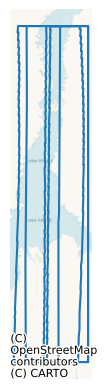

In [6]:
axes = data_frame.to_crs(epsg=3857).boundary.plot()
contextily.add_basemap(axes, source=contextily.providers.CartoDB.Voyager)
axes.set_axis_off()

If you happen to know your item (granule) id, you can fetch that item directly and see it's assets dictionary.

In [7]:
item = next(
    stac_client.search(collections=["satellogic"], ids=[SATELLOGIC_ITEM_ID]).items()
)
item

<Item id=20251123_221219_589_SN41_L1D_SR_MS_333174>

## Download assets

While the STAC API is open, the [CSDA Orders API](https://csdap.earthdata.nasa.gov/api) requires authentication.
You'll use your [Earthdata login](https://urs.earthdata.nasa.gov/) username and password to log in.

In [8]:
username = input("Earthdata username: ")
password = getpass.getpass("Earthdata password: ")

Logging into CSDA creates an access token that encodes your download quotas, among other information.

In [9]:
client = CsdaClient.open(BasicAuth(username=username, password=password))
client.verify()

'Hello shreyniraula, you have a valid token!'

First, let's see how much quota you have.
The example output has very large quotas, because it was run for a developer on the project who has artificially high quotas.

In [10]:
profile = client.profile(username)
rows = []
for vendor in profile.vendors:
    rows.append([vendor.vendor, vendor.quota, vendor.quota_unit])
tabulate.tabulate(rows, headers=["Vendor", "Quota", "Quota unit"], tablefmt="html")

Vendor,Quota,Quota unit
Satellogic,1000000000000,QuotaUnit.filesize
Planet,1000000000000,QuotaUnit.filesize


### For Satellogic

In [11]:
item_search = stac_client.search(
    collections=["satellogic"],
    ids=[SATELLOGIC_ITEM_ID],
)
item_collection = item_search.item_collection()
assert len(item_collection) == 1
data_frame = GeoDataFrame.from_features(item_collection.to_dict())
data_frame

,geometry,gsd,created,license,datetime,platform,proj:epsg,providers,instruments,satl:sat_id,...,eo:cloud_cover,view:off_nadir,satl:outcome_id,view:sun_azimuth,satl:exposure_sec,satl:product_name,view:sun_elevation,satl:product_version,view:incidence_angle,satl:satellite_generation
0,"POLYGON ((-114.39874 36.34958, -114.39903 36.3...",0.5,2025-11-24T04:35:34.631918Z,proprietary,2025-11-23T22:12:19.589151Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat41,...,0.0,7.23,6379604c-1579-4f60-8789-948cf8ce3933,222.472,0.006,L1D_SR,21.0,2.0.0,7.959,MarkV


The item has several assets.


In [12]:
item = item_collection[0]
rows = []
for key, asset in item.assets.items():
    if file_size := asset.ext.file.size:
        humanized_file_size = humanize.naturalsize(file_size)
    else:
        humanized_file_size = None
    if roles := asset.roles:
        humanized_roles = humanize.natural_list(roles)
    else:
        humanized_roles = roles
    rows.append([key, humanized_roles, asset.media_type, humanized_file_size])
tabulate.tabulate(
    rows, headers=["Key", "Roles", "Type", "File size", "Roles"], tablefmt="html"
)

Key,Roles,Type,File size
cloud,cloud,application/xml,1.5 kB
visual,data,application/xml,2.7 kB
preview,overview,image/png,16.5 MB
analytic,data,application/xml,3.2 kB
footprint,footprint,application/vnd.google-earth.kml+xml,3.4 kB
thumbnail,thumbnail,image/png,87.1 kB
vrt_cloud,data,image/tiff; application=geotiff,9.3 MB
vrt_visual,data,image/tiff; application=geotiff,1.7 GB
toa-factors,metadata,application/geo+json,183.4 kB
vrt_analytic,data,image/tiff; application=geotiff,5.0 GB


Let's download the vrt_cloud asset.


completed download, proceed to visualize


/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


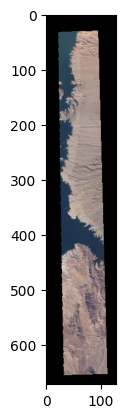

In [13]:
asset_key = "thumbnail"
with TemporaryDirectory() as temporary_directory:
    local_path = Path(temporary_directory) / f"{asset_key}.png"
    client.download_item(item, asset_key, local_path)
    print("completed download, proceed to visualize")
    with rasterio.open(local_path) as dataset:
        rasterio.plot.show(dataset)